Holiday Package Prediciton
1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv('Travel.csv')

In [3]:
df.head()


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Data Cleaning

In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [6]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')

In [8]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [9]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [10]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [11]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [12]:
features_na = [f for f in df.columns if df[f].isnull().sum()>0]

In [17]:
features_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [36]:
for f in features_na:
    print(f, ":     ", np.round(df[f].isnull().mean()*100,5))

Age :      4.62357
TypeofContact :      0.51146
DurationOfPitch :      5.13502
NumberOfFollowups :      0.92062
PreferredPropertyStar :      0.53191
NumberOfTrips :      2.86416
NumberOfChildrenVisiting :      1.35025
MonthlyIncome :      4.76678


In [37]:
df[features_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [35]:
sr.mean()

np.float64(0.7)

## Imputing Null values <br>
1. Impute Median value for Age column<br>
2. Impute Mode for Type of Contract<br>
3. Impute Median for Duration of Pitch<br>
4. Impute Mode for NumberofFollowup as it is Discrete feature<br>
5. Impute Mode for PreferredPropertyStar<br>
6. Impute Median for NumberofTrips<br>
7. Impute Mode for NumberOfChildrenVisiting<br>
8. Impute Median for MonthlyIncome<br>

In [48]:
print(df['TypeofContact'].mode()[0])
print("  ")
df['TypeofContact'].mode()

Self Enquiry
  


0    Self Enquiry
Name: TypeofContact, dtype: object

In [49]:
df['Age'].isnull().sum()

np.int64(226)

In [50]:
#Age
df.Age.fillna(df.Age.median(), inplace=True)

#TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

#DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

#PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

#NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

In [51]:
df['Age'].isnull().sum()

np.int64(0)

In [52]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [53]:
df.drop('CustomerID',inplace=True,axis=1)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   object 
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   object 
 6   Gender                    4888 non-null   object 
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   object 
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   object 
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSat

# Feature Engineering

In [56]:
df['ToatlVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(['NumberOfChildrenVisiting','NumberOfPersonVisiting'],inplace=True,axis=1)

In [58]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,ToatlVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [60]:
num_feature = [f for f in df.columns if df[f].dtype != 'object']
len(num_feature)

12

In [62]:
cat_feature = [f for f in df.columns if df[f].dtype == 'O']
len(cat_feature)

6

In [65]:
len(num_feature)+len(cat_feature) == len(df.columns)
#means all feature included 

True

In [69]:
discrete_feature = [f for f in num_feature if len(df[f].unique()) <= 25]
discrete_feature

['ProdTaken',
 'CityTier',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'ToatlVisiting']

In [70]:
continuous_feature = [f for f in num_feature if len(df[f].unique()) > 25]
continuous_feature

['Age', 'DurationOfPitch', 'MonthlyIncome']

In [71]:
len(discrete_feature)+len(continuous_feature) == len(num_feature)

True

In [87]:
from sklearn.model_selection import train_test_split
x = df.drop('ProdTaken',axis=1)
y = df['ProdTaken']

In [88]:
y.value_counts()
#binary classification

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [89]:
x.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,ToatlVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [90]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.23,random_state=42)
x_train.shape, x_test.shape

((3763, 17), (1125, 17))

In [91]:
cat_feature = x.select_dtypes(include='object').columns
num_feature = x.select_dtypes(exclude='object').columns

In [92]:
cat_feature

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [93]:
num_feature

Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'ToatlVisiting'],
      dtype='object')

In [94]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

oh_transformer = OneHotEncoder(drop='first')
scaler = StandardScaler()

preprocess = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_feature),
        ('StandardScaler', scaler, num_feature)
    ]
    )

In [95]:
x_train = preprocess.fit_transform(x_train)

In [96]:
x_train

array([[ 1.        ,  0.        ,  1.        , ..., -1.27728953,
        -0.33171062, -0.06289444],
       [ 1.        ,  0.        ,  1.        , ..., -1.27728953,
         1.6564947 ,  1.35430179],
       [ 1.        ,  1.        ,  0.        , ...,  0.78290785,
        -1.1770012 ,  0.64570368],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78290785,
        -0.35635466,  0.64570368],
       [ 1.        ,  0.        ,  0.        , ...,  0.78290785,
        -0.24886873,  0.64570368],
       [ 0.        ,  0.        ,  1.        , ..., -1.27728953,
        -1.07633977, -1.48009067]], shape=(3763, 26))

In [97]:
x_test = preprocess.transform(x_test)

In [98]:
x_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.27728953,
        -0.73227106, -0.77149255],
       [ 1.        ,  0.        ,  0.        , ..., -1.27728953,
        -0.66535301, -0.06289444],
       [ 1.        ,  0.        ,  0.        , ...,  0.78290785,
        -0.41644821, -0.77149255],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78290785,
        -0.47919572,  1.35430179],
       [ 0.        ,  0.        ,  1.        , ..., -1.27728953,
        -1.01776278, -0.77149255],
       [ 1.        ,  0.        ,  1.        , ..., -1.27728953,
        -0.39256244,  0.64570368]], shape=(1125, 26))

In [99]:
pd.DataFrame(x_test)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.451331,-0.287938,1.275919,-0.722946,-1.220173,-0.632808,-0.773822,-1.277290,-0.732271,-0.771493
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.364277,-0.531779,0.276068,0.530138,-1.220173,1.580257,1.410642,-1.277290,-0.665353,-0.062894
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.451331,0.809349,0.276068,-0.722946,0.961585,-0.632808,1.410642,0.782908,-0.416448,-0.771493
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.722777,2.516239,2.275770,-0.722946,1.507025,-0.632808,-0.045667,0.782908,-0.110104,0.645704
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.451331,-1.019462,0.276068,0.530138,-0.129294,1.580257,0.682488,0.782908,-0.312943,2.062900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.722777,0.199745,0.276068,1.783223,2.597904,-0.632808,-1.501976,0.782908,-0.265551,2.062900
1121,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,-0.722777,0.687428,-0.723783,0.530138,1.507025,-0.632808,-0.045667,0.782908,1.999995,-0.771493
1122,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.451331,-1.019462,2.275770,1.783223,-0.674733,-0.632808,-0.045667,0.782908,-0.479196,1.354302
1123,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.722777,-0.531779,0.276068,-0.722946,0.416146,-0.632808,-1.501976,-1.277290,-1.017763,-0.771493


# Training

In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,ConfusionMatrixDisplay

In [110]:
import sys
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier()
}

np.printoptions(threshold=sys.maxsize)

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    train_acc = accuracy_score(y_pred_train, y_train)
    train_precision = precision_score(y_pred_train, y_train)
    train_f1 = f1_score(y_pred_train, y_train, average='weighted')
    train_recall = recall_score(y_pred_train,y_train)
    train_roc_auc = roc_auc_score(y_pred_train,y_train)


    test_acc = accuracy_score(y_pred_test, y_test)
    test_precision = precision_score(y_pred_test, y_test)
    test_f1 = f1_score(y_pred_test, y_test, average='weighted')
    test_recall = recall_score(y_pred_test, y_test)
    test_roc_auc = roc_auc_score(y_pred_test, y_test)

    print(list(models.keys())[i])

    print("Model performance on Training data")
    print(f"Accuracy:   {train_acc}")
    print(f"Precision:   {train_precision}")
    print(f"Recall:   {train_recall}")
    print(f"F1 Score:   {train_f1}")
    print(f"ROC AUC Score:   {train_roc_auc}")
    print("-"*35)



    print("Model Performance on Test Data")
    
   
    print(f"Accuracy:   {test_acc}")
    print(f"Precision:   {test_precision}")
    print(f"Recall:   {test_recall}")
    print(f"F1 Score:   {test_f1}")
    print(f"ROC AUC Score:   {test_roc_auc}")

    print("="*35)
    print("\n")

Logistic Regression
Model performance on Training data
Accuracy:   0.8440074408716449
Precision:   0.302945301542777
Recall:   0.7058823529411765
F1 Score:   0.8702815142482019
ROC AUC Score:   0.7810580408038252
-----------------------------------
Model Performance on Test Data
Accuracy:   0.8417777777777777
Precision:   0.30434782608695654
Recall:   0.6494845360824743
F1 Score:   0.8659316576813737
ROC AUC Score:   0.7547033575354005


Decision Tree
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Data
Accuracy:   0.912
Precision:   0.7874396135265701
Recall:   0.7477064220183486
F1 Score:   0.9111263819500403
ROC AUC Score:   0.8495974226960542


Random Forest
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Data
Accuracy: 

In [111]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [112]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [113]:
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params)
                   ]

In [114]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(x_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for RF -------------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


In [115]:
import sys
models = {
    "Random Forest" : RandomForestClassifier(n_estimators=100,min_samples_split=2,max_features=8,max_depth=None)
}

np.printoptions(threshold=sys.maxsize)

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    train_acc = accuracy_score(y_pred_train, y_train)
    train_precision = precision_score(y_pred_train, y_train)
    train_f1 = f1_score(y_pred_train, y_train, average='weighted')
    train_recall = recall_score(y_pred_train,y_train)
    train_roc_auc = roc_auc_score(y_pred_train,y_train)


    test_acc = accuracy_score(y_pred_test, y_test)
    test_precision = precision_score(y_pred_test, y_test)
    test_f1 = f1_score(y_pred_test, y_test, average='weighted')
    test_recall = recall_score(y_pred_test, y_test)
    test_roc_auc = roc_auc_score(y_pred_test, y_test)

    print(list(models.keys())[i])

    print("Model performance on Training data")
    print(f"Accuracy:   {train_acc}")
    print(f"Precision:   {train_precision}")
    print(f"Recall:   {train_recall}")
    print(f"F1 Score:   {train_f1}")
    print(f"ROC AUC Score:   {train_roc_auc}")
    print("-"*35)



    print("Model Performance on Test Data")
    
   
    print(f"Accuracy:   {test_acc}")
    print(f"Precision:   {test_precision}")
    print(f"Recall:   {test_recall}")
    print(f"F1 Score:   {test_f1}")
    print(f"ROC AUC Score:   {test_roc_auc}")

    print("="*35)
    print("\n")

Random Forest
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Data
Accuracy:   0.9431111111111111
Precision:   0.7198067632850241
Recall:   0.9612903225806452
F1 Score:   0.9464136259117062
ROC AUC Score:   0.9507482540738278




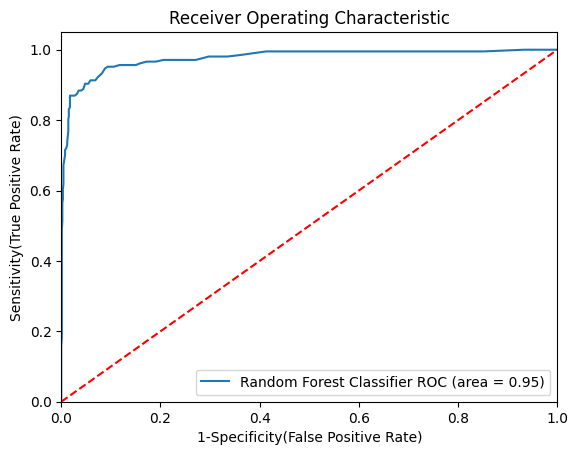

In [117]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    "model" : RandomForestClassifier(n_estimators=100,min_samples_split=2,max_features=8,max_depth=None),
    'auc':  0.9507
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 